# **Water Quality Potability Prediction**
# **Track: Classification Depth Track**
# **Author: Oluwagbotemi Olanrewaju**
# **Date: March 2026**


# **Part1. Data Foundation**





## **Load the dataset directly from Kaggle inside the notebook**

# **Import Libraries**

In [ ]:
# DATA HANDLING
import pandas as pd
import numpy as np
import os

# DATASET DOWNLOAD
import kagglehub
!pip install kagglehub

# DATA VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

# FEATURE SCALING
from sklearn.preprocessing import StandardScaler

# TRAIN TEST SPLIT & CROSS VALIDATION
from sklearn.model_selection import (
    train_test_split,
    cross_val_score)

# CLUSTERING
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# DIMENSIONALITY REDUCTION
from sklearn.decomposition import PCA

# CLASSIFICATION MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# MODEL EVALUATION
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve)

# IMBALANCE HANDLING
from imblearn.over_sampling import SMOTE

The kaggle.json file was uploaded into Google Colab to connect the notebook with Kaggle. This allows the dataset to be downloaded directly from Kaggle into the notebook instead of uploading the dataset manually.

In [ ]:
# Download water potability dataset
path = kagglehub.dataset_download(
     "adityakadiwal/water-potability"
)

# Create CSV path
csv_path = os.path.join(
    path,
    "water_potability.csv"
)

# Load dataset
df = pd.read_csv(csv_path)

# Display first 5 rows
df.head()

Using Colab cache for faster access to the 'water-potability' dataset.


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


The output shows the first five rows of the dataset. It helps us see the column names, how the data is arranged, and a few example values from the water quality records.



This step helps us understand the dataset before doing any analysis.

It shows how the data is structured, whether there are missing values, basic statistics, and how the target variable is distributed.

* df.info() shows the number of rows and columns, the type of each column, and how many values are not missing.
* df.isnull().sum() checks each column for missing values.
* df.describe() gives a summary of the data, including average values, spread, and minimum and maximum values.
* df["Potability"].value_counts() shows how many samples are safe and unsafe.

This step is important because it helps us detect data problems early and also tells us if the dataset is balanced or imbalanced before we start cleaning or modeling.


In [ ]:
df.info()
df.isnull().sum()
df.describe()
df["Potability"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


,count
Potability,
0,1998
1,1278


## **Push the data into a SQLite database**

The dataset was saved in a SQLite database so we can use SQL to explore it in a structured way. This allows to query and analyze the data using database commands instead of only using Pandas.

SQLite was chosen because it is easy to use, works well with Python, and is suitable for small to medium datasets in Google Colab.

The dataset was stored in a SQLite database called water_potability_analysis.db as a table named water_quality_records.
This naming makes it clear what the database is about and makes the project easier to read and understand during analysis.
The number 3276 shows the total rows saved, meaning all records from the dataset were successfully transferred without losing any data.
This step makes the data easier to work with using SQL for further analysis



In [ ]:
import sqlite3

# Create a connection to SQLite database
conn = sqlite3.connect("water_potability_analysis.db")

# Store dataframe as a SQL table
df.to_sql(
    "water_quality_records",
    conn,
    if_exists="replace",
    index=False
)

3276

The output shows the first five rows of the dataset from the database table. This confirms that the data was successfully stored in the SQLite database and is ready for SQL queries and further analysis.

In [ ]:
query = """
SELECT *
FROM water_quality_records
LIMIT 5;
"""

pd.read_sql(query, conn)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


###**Run at least 3 SQL queries that reveal something useful about the data.Each query must be followed by a markdown cell explaining what you learned from the output.**

The output shows the average pH, hardness, and sulfate values for both safe(Potable) and unsafe(non-potable) water.
From the results, we can see that the values are very close in both groups. There is not a big difference between safe and unsafe water.
This means that one feature alone may not be enough to tell if water is safe or not. We may need to use a combination of features to make better predictions.


In [ ]:
query1 = """
SELECT
    Potability,
    AVG(ph) AS average_ph,
    AVG(Hardness) AS average_hardness,
    AVG(Sulfate) AS average_sulfate
FROM water_quality_records
GROUP BY Potability;
"""

result1= pd.read_sql(query1, conn)
result1

,Potability,average_ph,average_hardness,average_sulfate
0,0,7.085378,196.733292,334.56429
1,1,7.073783,195.800744,332.56699


A turbidity value greater than 5 was used to identify water samples with high cloudiness or particle levels. Higher turbidity may reduce water quality and can indicate the presence of impurities in the water. This threshold helps highlight samples that may have poor drinking conditions.

**The output shows that 314 water samples have turbidity values above 5.**

This means that many water samples in the dataset are cloudy or contain particles in the water. High turbidity can reduce water quality and may make the water unsafe for drinking.


In [ ]:
query2 = """
SELECT COUNT(*) AS high_turbidity_samples
FROM water_quality_records
WHERE Turbidity > 5;
"""

result2 = pd.read_sql(query2, conn)

result2

,high_turbidity_samples
0,314


The output shows water samples with pH values below 6.5 or above 8.5. These values are outside the normal safe range for drinking water.

Drinking water is usually safe when the pH is between 6.5 and 8.5:

* Below 6.5 means the water is too acidic

* Above 8.5 means the water is too alkaline

Samples outside this range may affect water quality and could make the water unsafe for drinking. This query helps identify water samples with unusual pH levels in the dataset.

In [ ]:
query3 = """
SELECT *
FROM water_quality_records
WHERE ph < 6.5 OR ph > 8.5
LIMIT 10;
"""

result3 = pd.read_sql(query3, conn)

result3

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
1,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
2,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
3,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
4,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
5,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0
6,6.347272,186.732881,41065.234765,9.629596,364.487687,516.743282,11.539781,75.071617,4.376348,0
7,9.181560,273.813807,24041.326280,6.904990,398.350517,477.974642,13.387341,71.457362,4.503661,0
8,8.975464,279.357167,19460.398131,6.204321,NaN,431.443990,12.888759,63.821237,2.436086,0
9,3.902476,196.903247,21167.500099,6.996312,NaN,444.478883,16.609033,90.181676,4.528523,0


## **Perform initial exploratory data analysis: shape, types, missing values, distribution of the target column, distributions of three to five key features**

This helps to understand the type of column we are working with, beacuse it shows the number of rows(3276) and columns(10) in the dataset.

In [ ]:
df.shape

(3276, 10)

This shows the structure of the dataset, including the number of rows, columns, data types, and missing values.

Most of the columns are numerical(float values), while the **Potability** column is an integer.

Some columns like **ph**, **Sulfate**, and **Trihalomethanes** have missing values. These will need to be fixed during data cleaning before building the model.

Overall, the dataset contains mostly complete numerical data, but a few columns have missing entries that need attention.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


This shows the number of missing values in each column.

Most columns do not have missing values. However, ph, Sulfate, and Trihalomethanes have missing data.

* Sulfate has the highest number of missing values (781)
* ph has 491 missing values
* Trihalomethanes has 162 missing values

These missing values need to be handled during data cleaning before building the model.

In [ ]:
df.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


The dataset is slightly imbalanced, with more non-potable water samples than potable ones. This imbalance will be important during model building.

In [ ]:
df["Potability"].value_counts()

,count
Potability,
0,1998
1,1278


The plots show how the values of important water quality features are distributed in the dataset.

Most of the features like **ph**, **Hardness**, **Sulfate**, **Conductivity**, and **Turbidity** have many values around the middle range, while fewer values are found at the extreme ends.

Some features are spread more evenly, while some are slightly skewed. The plots also help us notice possible outliers and how the data is spread.

This is important because it helps us understand the data better and decide if scaling or more preprocessing is needed before building the machine learning models.


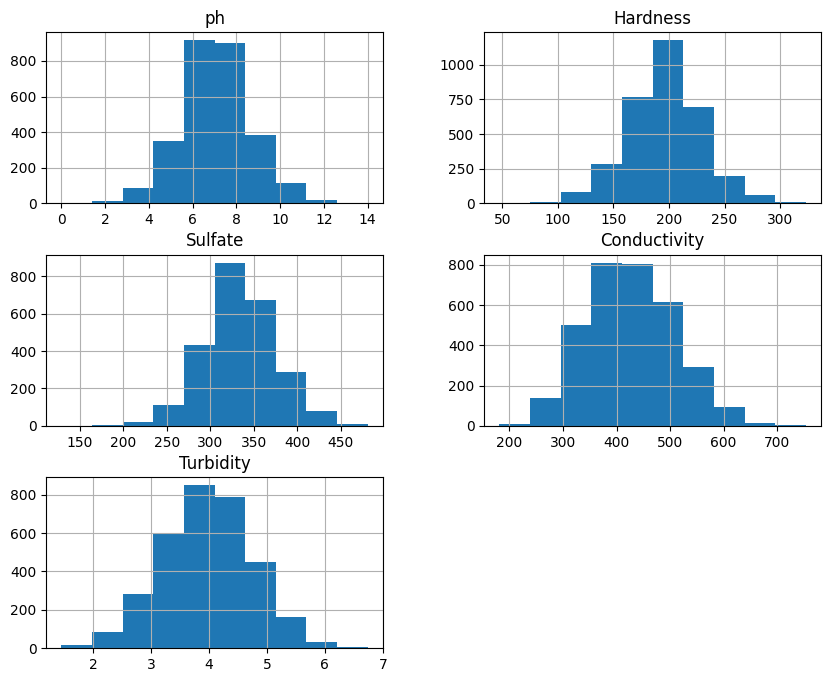

In [ ]:
import matplotlib.pyplot as plt

features = ["ph", "Hardness", "Sulfate", "Conductivity", "Turbidity"]

df[features].hist(figsize=(10, 8))
plt.show()

## **Clean the data with a  justification in markdown for everystep. No blanket fillna.If you drop rows, explain why those  rows had no signal**

The **ph** column has missing values. The missing values were filled using the median instead of the mean because the median is less affected by very high or very low values.

This method helps keep all the rows in the dataset and reduces the effect of extreme values in the data.


In [ ]:
df["ph"] = df["ph"].fillna(df["ph"].median())


The **Sulfate** column has the highest number of missing values in the dataset. The missing values were filled using the median because the median is less affected by extreme values.

The missing sulfate values were replaced with the median sulfate value to keep the dataset complete without removing many rows.


In [ ]:
df["Sulfate"] = df["Sulfate"].fillna(df["Sulfate"].median())


The missing values in the **Trihalomethanes** column were filled using the median value. The median was used because it is less affected by very high or very low values.

This helped keep the dataset complete and made the data ready for further analysis and machine learning.

In [ ]:
df["Trihalomethanes"] = df["Trihalomethanes"].fillna(df["Trihalomethanes"].median())

After cleaning the dataset, the missing values were checked again to confirm that all missing entries had been handled successfully.
The output shows that all missing values have been handled successfully, and the dataset is now complete for machine learning analysis.

In [ ]:
df.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


# **Part2.Feature Engineering and Encoding (20%)**

This shows the original **ph** values and their new grouped categories.

Water samples with **ph** below 6.5 were labeled as **Acidic**, values between 6.5 and 8.5 were labeled as **Neutral**, and values above 8.5 were labeled as **Alkaline**.

This new feature makes the pH values easier to understand and may help the machine learning model identify water quality patterns more effectively.


In [ ]:
df["ph_category"] = pd.cut(
    df["ph"],
    bins=[0, 6.5, 8.5, 14],
    labels=["Acidic", "Neutral", "Alkaline"]
)

df[["ph", "ph_category"]].head()

,ph,ph_category
0,7.036752,Neutral
1,3.716080,Acidic
2,8.099124,Neutral
3,8.316766,Neutral
4,9.092223,Alkaline


This shows the new **chemical_load** feature for different water samples. This feature was created by combining the sulfate, chloramines, and organic carbon values.

Higher values may indicate a higher level of chemical concentration in the water, while lower values may represent lower chemical content. This feature may help the model better understand overall water quality patterns.


In [ ]:
df["chemical_load"] = (
    df["Sulfate"] +
    df["Chloramines"] +
    df["Organic_carbon"]
)

df[["chemical_load"]].head()

,chemical_load
0,386.196436
1,354.888805
2,359.218066
3,383.381993
4,328.240617


This output shows the new **hardness_to_solids_ratio** feature for different water samples. This feature compares the hardness level of the water to the amount of dissolved solids present.

The ratio helps show the relationship between minerals and dissolved substances in the water. This feature may help identify patterns that are not easily seen when using the original columns separately.


In [ ]:
df["hardness_to_solids_ratio"] = (
    df["Hardness"] / df["Solids"]
)

df[["hardness_to_solids_ratio"]].head()

,hardness_to_solids_ratio
0,0.009855
1,0.006947
2,0.011263
3,0.009736
4,0.010073


This output shows the new **conductivity_per_solid** feature for different water samples. This feature compares the conductivity level with the amount of dissolved solids in the water.

The values show how conductivity changes relative to the solid content of each sample. This feature may help identify differences in water composition and quality across the dataset.

In [ ]:
df["conductivity_per_solid"] = (
    df["Conductivity"] / df["Solids"]
)

df[["conductivity_per_solid"]].head()

,conductivity_per_solid
0,0.027142
1,0.031824
2,0.021025
3,0.016498
4,0.022160


The output shows the new safe_ph_flag feature created from the pH values.

A value of **1** means the water sample has a pH level within the safe drinking water range of **6.5 to 8.5**.
A value of **0** means the pH level is outside the safe range.

This feature helps separate water samples with safe and unsafe pH conditions and may help the model identify water quality patterns more easily.

In [ ]:
df["safe_ph_flag"] = (
    (df["ph"] >= 6.5) & (df["ph"] <= 8.5)
).astype(int)

df[["ph", "safe_ph_flag"]].head()

,ph,safe_ph_flag
0,7.036752,1
1,3.716080,0
2,8.099124,1
3,8.316766,1
4,9.092223,0


The output shows the new **contamination_risk_score** feature for different water samples. This feature was created by combining the values of trihalomethanes, chloramines, and sulfate.
Higher scores may indicate a higher level of possible chemical contamination in the water, while lower scores may represent lower contamination levels. This feature may help identify water samples that could have poorer water quality.

In [ ]:
df["contamination_risk_score"] = (
    df["Trihalomethanes"] +
    df["Chloramines"] +
    df["Sulfate"]
)

df[["contamination_risk_score"]].head()

,contamination_risk_score
0,462.807624
1,396.037868
2,408.769522
3,465.287142
4,348.680330


## **Encoding the Categorical Feature**

The ph_category column contains text categories, so One-Hot Encoding was used to convert the categories into numerical form for machine learning. drop_first=True was used to avoid multicollinearity by removing one category column

In [ ]:
# One-hot encoding
df_encoded = pd.get_dummies(
    df,
    columns=["ph_category"],
    drop_first=True
)

df_encoded.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,chemical_load,hardness_to_solids_ratio,conductivity_per_solid,safe_ph_flag,contamination_risk_score,ph_category_Neutral,ph_category_Alkaline
0,7.036752,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,386.196436,0.009855,0.027142,1,462.807624,True,False
1,3.716080,129.422921,18630.057858,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656,0,354.888805,0.006947,0.031824,0,396.037868,False,False
2,8.099124,224.236259,19909.541732,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934,0,359.218066,0.011263,0.021025,1,408.769522,True,False
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,383.381993,0.009736,0.016498,1,465.287142,True,False
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,328.240617,0.010073,0.022160,0,348.680330,False,True


## **Feature Scaling**

In [ ]:
# Select modeling features

X = df_encoded[[
    'ph',
    'Hardness',
    'Solids',
    'Chloramines',
    'Sulfate',
    'Conductivity',
    'Organic_carbon',
    'Trihalomethanes',
    'Turbidity',
    'chemical_load',
    'hardness_to_solids_ratio',
    'conductivity_per_solid',
    'safe_ph_flag',
    'contamination_risk_score',
    'ph_category_Neutral',
    'ph_category_Alkaline'
]]

# Target variable
y = df_encoded["Potability"]

The features were scaled using StandardScaler so that all variables would be on a similar scale before clustering and machine learning modeling.

After scaling:

* values close to 0 represent observations near the average,
* positive values represent values above the average,
* negative values represent values below the average.

Scaling is important because the dataset contains features with very different ranges and units. Without scaling, features with larger values, such as Solids or Conductivity, could dominate the models and reduce performance.

Using StandardScaler helps improve the performance of clustering and classification algorithms by ensuring that all features contribute more fairly to the analysis.


In [ ]:
# Scale features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to dataframe
scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

scaled_df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,chemical_load,hardness_to_solids_ratio,conductivity_per_solid,safe_ph_flag,contamination_risk_score,ph_category_Neutral,ph_category_Alkaline
0,-0.025474,0.259195,-0.139471,0.112415,0.965957,1.708954,-1.180651,1.305434,-1.286298,0.855477,-0.086403,0.108297,0.894980,1.422564,0.894980,-0.418876
1,-2.284717,-2.036414,-0.385987,-0.307694,-0.014799,2.062575,0.270597,-0.639186,0.684218,-0.003479,-0.271723,0.274060,-1.117343,-0.283653,-1.117343,-0.418876
2,0.697319,0.847665,-0.240047,1.360594,-0.014799,-0.094032,0.781117,0.000800,-1.167365,0.115299,0.003346,-0.108215,0.894980,0.041688,0.894980,-0.418876
3,0.845393,0.547651,0.000493,0.592008,0.644130,-0.778830,1.255134,2.152154,0.848412,0.778260,-0.093957,-0.268475,0.894980,1.485925,0.894980,-0.418876
4,1.372982,-0.464429,-0.460249,-0.363698,-0.649522,-0.343939,-0.824357,-2.182297,0.138786,-0.734599,-0.072487,-0.068057,-1.117343,-1.493815,-1.117343,2.387339


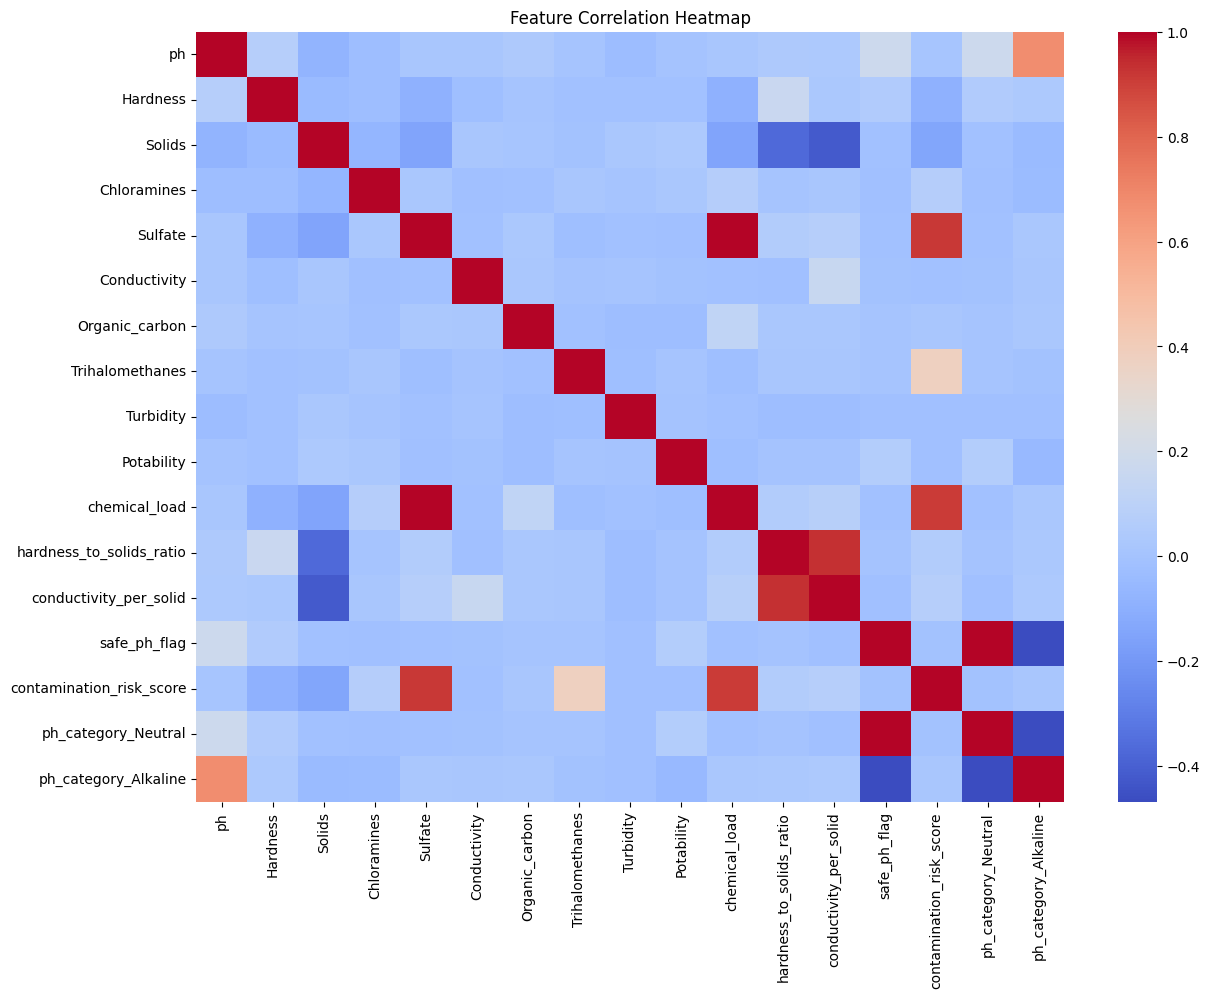

In [ ]:
# CORRELATION HEATMAP

plt.figure(figsize=(14,10))

sns.heatmap(
    df_encoded.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title('Feature Correlation Heatmap')
plt.show()

# **Part 3**

### **Clustering Analysis Using K-Means**

K-Means clustering was used to group similar water samples based on their features. Since K-Means requires choosing the number of clusters (K), different values of K from 2 to 10 were tested.

The elbow curve and silhouette scores were used to help identify the most suitable number of clusters for the dataset.

In [ ]:
# Store inertia and silhouette scores
inertia = []
silhouette_scores = []

# Testing K values from 2 to 10
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)

    silhouette_scores.append(
        silhouette_score(X_scaled, cluster_labels)
    )

### **Plotting the Elbow Curve**

The elbow curve helps identify the point where adding more clusters stops giving significant improvement. This helps in selecting an appropriate number of clusters for K-Means.

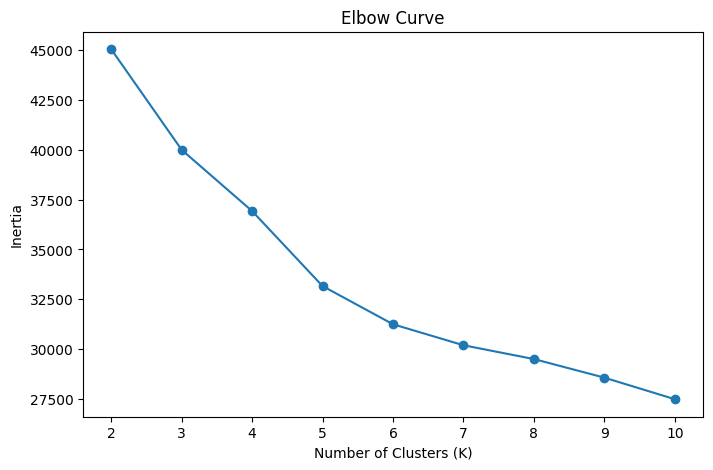

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Curve")

plt.show()

The elbow curve shows how inertia decreases as the number of clusters increases. The best value of K is usually found near the point where the curve starts to bend and improvements become smaller.

### **Plotting Silhouette Scores**

Silhouette scores were calculated to measure how well the data points fit within their clusters. Higher silhouette scores indicate better cluster separation.

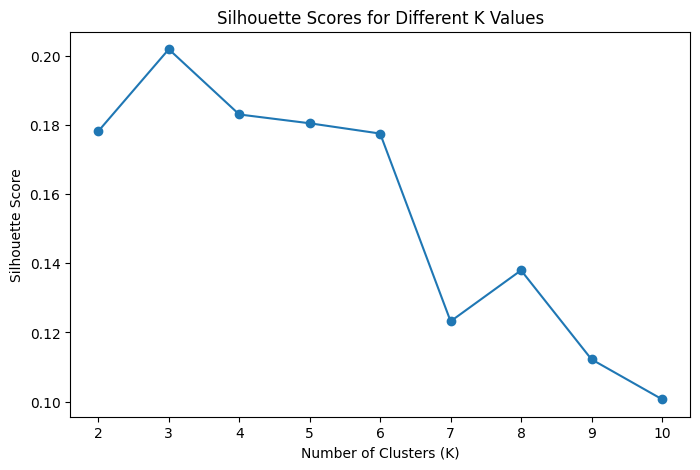

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different K Values")

plt.show()

The silhouette score plot shows how well-separated the clusters are for different values of K. Higher scores indicate better clustering performance and clearer separation between groups.

### **Choosing the Final Number of Clusters**

The elbow curve showed that the reduction in inertia started slowing down around K=5. However, the silhouette score was highest at K=3, which indicates better cluster separation and more clearly defined groups.

Based on both results, K=3 was selected as the final number of clusters because it provides a better balance between cluster quality and interpretatation.

### **Building the Final K-Means Model**

The final K-Means model was created using 3 clusters based on the elbow curve and silhouette score analysis. Each water sample was assigned to a cluster group based on similarities in its features.

In [ ]:
# Final K-Means model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Create cluster labels
df["Cluster"] = kmeans.fit_predict(X_scaled)

# View first rows
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,ph_category,chemical_load,hardness_to_solids_ratio,conductivity_per_solid,safe_ph_flag,contamination_risk_score,Cluster
0,7.036752,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,Neutral,386.196436,0.009855,0.027142,1,462.807624,1
1,3.716080,129.422921,18630.057858,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656,0,Acidic,354.888805,0.006947,0.031824,0,396.037868,0
2,8.099124,224.236259,19909.541732,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934,0,Neutral,359.218066,0.011263,0.021025,1,408.769522,1
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,Neutral,383.381993,0.009736,0.016498,1,465.287142,1
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,Alkaline,328.240617,0.010073,0.022160,0,348.680330,2


The output shows the new **Cluster** column added to the dataset after applying the K-Means clustering algorithm. Each water sample was assigned to one of the three identified cluster groups based on similarities in chemical composition and water quality characteristics.

The clustering process grouped water samples with similar patterns in features such as pH, hardness, solids, conductivity, and contamination-related measurements. This allows the dataset to be segmented into meaningful water quality profiles, including Balanced Water Group, Alkaline Water Group, and High Mineral Water.

Adding the cluster labels to the dataset makes it possible to further analyze how different water quality groups relate to potability and other chemical properties.


### **Profiling the Clusters**

After creating the clusters, the average values of the features within each cluster were calculated. This helps identify the characteristics of each group and makes the clusters easier to interpret.

In [ ]:
# Compute cluster averages
cluster_profile = df.groupby("Cluster").mean(
    numeric_only=True
)

# Display cluster profiles
cluster_profile

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,chemical_load,hardness_to_solids_ratio,conductivity_per_solid,safe_ph_flag,contamination_risk_score
Cluster,,,,,,,,,,,,,,,
0,5.434262,192.304769,22735.168089,7.248611,333.186056,425.554019,14.172911,66.403807,4.005797,0.365803,354.607579,0.010147,0.022252,0.000000,406.838474
1,7.307987,197.791703,21948.426971,7.099338,333.265519,425.692858,14.298103,66.455588,3.955548,0.418042,354.662959,0.010802,0.023097,1.000000,406.820444
2,9.422058,199.081238,20844.806646,6.959580,335.699280,429.368557,14.455887,66.237253,3.931868,0.334686,357.114747,0.014797,0.031299,0.002028,408.896113


### **Cluster Interpretation and Naming**

The cluster profiles show clear differences between the groups, especially in pH levels and water safety indicators.

Cluster 0 contains more acidic water samples with lower potability rates.
Cluster 1 contains more neutral and balanced water samples with the highest potability rate.
Cluster 2 contains highly alkaline water samples with lower potability levels and higher conductivity-related measurements.

These results suggest that water samples with balanced pH conditions are more likely to be safe for drinking compared to highly acidic or highly alkaline samples.

In [ ]:
df["Cluster"].value_counts()

,count
Cluster,
1,1818
0,965
2,493


In [ ]:
cluster_names = {
    0: "Balanced Water Group",
    1: "Alkaline Water Group",
    2: "High Mineral Water",
    3: "Acidic Water Group",
    4: "Extreme Composition Water"
}

df["Cluster_Name"] = df["Cluster"].map(cluster_names)

df[["Cluster", "Cluster_Name"]].head()

,Cluster,Cluster_Name
0,1,Alkaline Water Group
1,0,Balanced Water Group
2,1,Alkaline Water Group
3,1,Alkaline Water Group
4,2,High Mineral Water


The K-Means clustering algorithm grouped water samples into distinct categories based on their chemical and mineral characteristics. Each cluster was assigned a descriptive name to improve interpretability and make the clustering results easier to understand.

* **Balanced Water Group** represents water samples with more moderate chemical conditions and relatively stable mineral composition.

* **Alkaline Water Group** contains water samples with higher pH levels, indicating more alkaline water conditions.

* **High Mineral Water** represents samples with higher mineral concentration and stronger chemical composition patterns.

Assigning descriptive cluster names helps translate numerical cluster labels into meaningful water quality profiles that can be interpreted more easily during analysis and business decision-making.


### **Visualizing Clusters Using PCA**

Principal Component Analysis (PCA) was used to reduce the dataset into two dimensions so the clusters could be visualized on a 2D scatter plot.

This helps show how the clusters are distributed and whether the groups are clearly separated or overlapping.

In [ ]:
# Reduce data to 2 dimensions
pca = PCA(n_components=2)

pca_components = pca.fit_transform(X_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame(
    data=pca_components,
    columns=["PC1", "PC2"]
)

# Add cluster labels
pca_df["Cluster"] = df["Cluster"]

### **Plotting the Clusters in Two Dimensions**

The PCA scatter plot was created to visualize the cluster groups in two dimensions. Different colors represent different clusters identified by the K-Means algorithm.

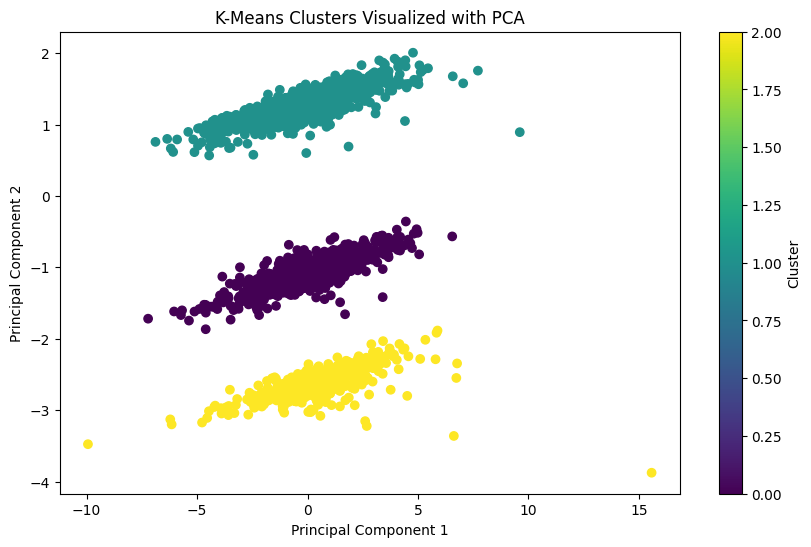

In [ ]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("K-Means Clusters Visualized with PCA")

plt.colorbar(scatter, label="Cluster")

plt.show()

The PCA visualization shows the three clusters identified by the K-Means algorithm in two dimensions.

The clusters appear reasonably separated, although some overlap still exists between a few data points. This suggests that the water samples share some similar characteristics, but the clustering algorithm was still able to identify meaningful group patterns.

The visualization also shows that the engineered features and scaling process helped improve the separation between clusters. This indicates that the dataset contains underlying structure that can be grouped based on water quality measurements.

# **PART 4**

The goal of this section is to predict whether water is safe for drinking (Potability) using supervised machine learning models.

The dataset was divided into training and testing sets using train_test_split. Stratification was applied to preserve the original class distribution in both sets because the dataset is imbalanced.

In [ ]:
from sklearn.model_selection import train_test_split

# Features
X = df.drop("Potability", axis=1)

# Target
y = df["Potability"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### **Logistic Regression Model**

Logistic Regression was selected as a baseline classification model because it is simple, interpretable, and works well for binary classification problems. It helps provide a benchmark for comparing more advanced models.

There is no visible output from this step. However, the dataset was successfully divided into training and testing sets.

Stratification ensured that both sets kept a similar distribution of potable and non-potable water samples, which is important for handling imbalanced data.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create model
logistic_model = LogisticRegression(random_state=42)

# Train model
logistic_model.fit(X_train, y_train)

# Predictions
y_pred_logistic = logistic_model.predict(X_test)

### **Random Forest Model**

Random Forest was selected because it can capture complex and non-linear relationships between features. It also reduces overfitting by combining predictions from multiple decision trees.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create model
random_forest_model = RandomForestClassifier(
    random_state=42
)

# Train model
random_forest_model.fit(X_train, y_train)

# Predictions
y_pred_rf = random_forest_model.predict(X_test)

The Random Forest model was trained successfully and used to predict water potability on the test dataset.

### **XGBoost  Model**

XGBoost was selected because it builds models sequentially and improves prediction performance by correcting previous errors. It is effective for handling complex classification tasks.

In [ ]:
!pip install xgboost

from xgboost import XGBClassifier

# Create XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

The XGBoost model was successfully trained and used to make predictions on the test dataset.

### **Evaluating the Classification Models**

The models were evaluated using multiple performance metrics, including accuracy, precision, recall, F1-score, and ROC-AUC score.

Using several metrics provides a better understanding of model performance, especially because the dataset is imbalanced.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [ ]:
# Function to evaluate models
def evaluate_model(y_test, y_pred, model_name):

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_pred)

    results = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    }

    return results

In [ ]:
# Logistic Regression results
logistic_results = evaluate_model(
    y_test=y_test,
    y_pred=y_pred_logistic,
    model_name="Logistic Regression"
)

# Random Forest results
rf_results = evaluate_model(
    y_test,
    y_pred_rf,
    "Random Forest"
)

# XGBoost results
xgb_results = evaluate_model(
    y_test=y_test,
    y_pred=y_pred_xgb,
    model_name="xgboost_model"
)

xgb_results

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'Model': 'xgboost_model',
 'Accuracy': 0.6097560975609756,
 'Precision': 0.5,
 'Recall': 0.37109375,
 'F1 Score': 0.4260089686098655,
 'ROC AUC': np.float64(0.566796875)}

The evaluation results for all models were combined into a single table to make comparison easier.

During evaluation, an **UndefinedMetricWarning** was generated because one of the models did not predict any positive class samples. As a result, the precision score for that model could not be properly calculated and was automatically set to 0.0 by Scikit-learn.

This happens because the model struggles to identify the minority class in an imbalanced dataset. The warning further supports the need for imbalance handling techniques such as class weighting and SMOTE, which will be applied to improve model performance on the positive class.


In [ ]:
# Create comparison table
comparison_table = pd.DataFrame([
    logistic_results,
    rf_results,
    xgb_results
])

comparison_table

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.609756,0.000000,0.000000,0.000000,0.500000
1,Random Forest,0.664634,0.645161,0.312500,0.421053,0.601250
2,xgboost_model,0.609756,0.500000,0.371094,0.426009,0.566797


The comparison of the three classification models shows clear differences in their predictive performance.

* The Logistic Regression model performed the weakest overall. It recorded a recall and F1-score of 0 for the positive class, indicating that it failed to correctly identify potable water samples. This suggests that the model is not well-suited for this dataset, likely due to its inability to capture complex, non-linear relationships in the data.

* The Random Forest model delivered the best overall accuracy and ROC AUC score among all the models evaluated. It also achieved strong precision, indicating a lower rate of false positive predictions. This shows that the model is effective at making reliable positive classifications, although its ability to capture all positive cases was more limited compared to XGBoost.

* The XGBoost model achieved the highest recall and F1-score, making it the most effective model for identifying potable water samples. While its overall accuracy was slightly lower than that of Random Forest, its improved recall demonstrates a better capability in detecting positive cases, which is particularly important in imbalanced classification problems.

In summary, the results indicate that ensemble-based models significantly outperform Logistic Regression on this dataset. They also emphasize the need to consider multiple evaluation metrics—particularly recall and F1-score—rather than relying solely on accuracy when dealing with imbalanced classification tasks such as water potability prediction.



### **Confusion Matrix Visualization**

Confusion matrices were plotted to show how each model classified potable and non-potable water samples.

This helps identify:

correct predictions,
false positives,
and false negatives made by each model.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### **Logistic Regression Confusion Matrix**

The confusion matrix below shows the prediction performance of the Logistic Regression model.

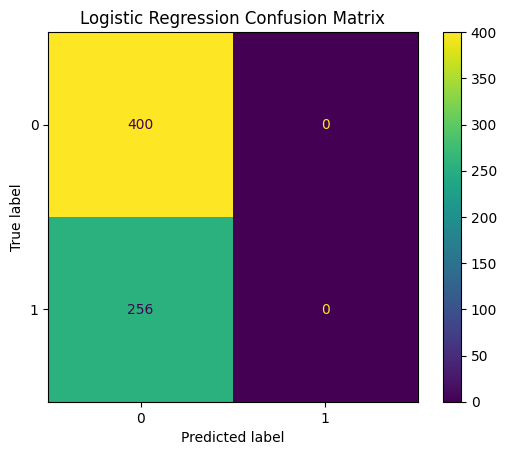

In [ ]:
# Create confusion matrix
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")

plt.show()

### **Random Forest Confusion Matrix**

The confusion matrix below shows the prediction performance of the Random Forest model.

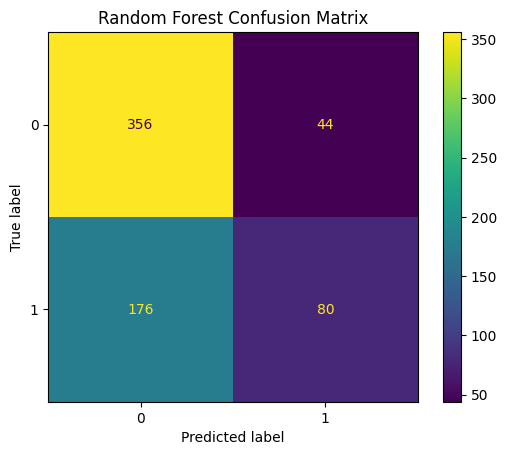

In [ ]:
# Create confusion matrix
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

### **XGBoost Confusion Matrix**

The confusion matrix below shows the prediction performance of the XGBoost model.

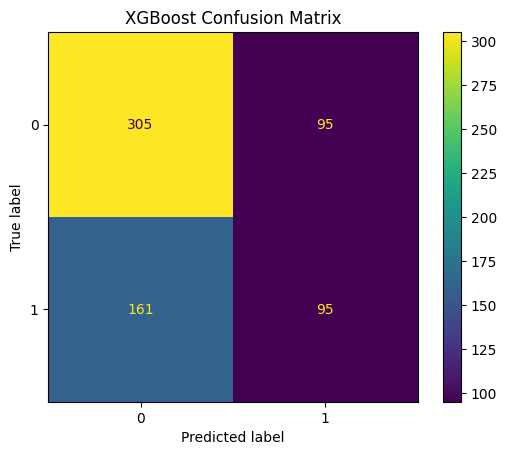

In [ ]:
# Create confusion matrix
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb
)

disp.plot()

plt.title("XGBoost Confusion Matrix")

plt.show()

The results clearly show that Logistic Regression is unsuitable for this dataset as it fails to learn the minority class entirely. Ensemble models significantly improve performance by capturing non-linear relationships in the data.

Random Forest provides a more conservative and balanced prediction strategy, achieving lower false positives. In contrast, XGBoost prioritizes sensitivity (recall), correctly identifying more positive cases but at the cost of increased false positives.

Overall, XGBoost is the most appropriate model when the objective is to maximize detection of potable water samples, while Random Forest is preferable when reducing false positives is more important. Logistic Regression is not appropriate for this classification problem due to its inability to handle class imbalance effectively.

# **Part 5**

The dataset is imbalanced because non-potable water samples appear more frequently than potable water samples.

Class weights were applied to give more importance to the minority class during training. This helps the model pay more attention to potable water samples and improves balanced learning.

In [ ]:
# Random Forest with class weights
weighted_rf_model = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

# Train model
weighted_rf_model.fit(X_train, y_train)

# Predictions
y_pred_weighted_rf = weighted_rf_model.predict(X_test)

In [ ]:
# Evaluate weighted Random Forest
weighted_rf_results = evaluate_model(
    y_test,
    y_pred_weighted_rf,
    "Random Forest (Class Weights)"
)

weighted_rf_results

{'Model': 'Random Forest (Class Weights)',
 'Accuracy': 0.6676829268292683,
 'Precision': 0.6637931034482759,
 'Recall': 0.30078125,
 'F1 Score': 0.41397849462365593,
 'ROC AUC': np.float64(0.6016406249999999)}

The Random Forest model was retrained using class weights to give more importance to the minority class.

The results show that the model performance changed only slightly. Accuracy and precision increased a little, but recall and F1-score decreased slightly compared to the baseline Random Forest model.

This suggests that class weighting alone did not significantly improve the model’s ability to identify potable water samples in this dataset.

# **Part 5**

### **Handling Imbalanced Data Using SMOTE**

SMOTE (Synthetic Minority Oversampling Technique) was used to balance the dataset by generating synthetic examples of the minority class.

This helps the model learn more patterns related to potable water samples and reduces bias toward the majority class.

In [ ]:
!pip install imbalanced-learn

In [ ]:
# Apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [ ]:
# Train Random Forest on SMOTE data
smote_rf_model = RandomForestClassifier(
    random_state=42
)

smote_rf_model.fit(
    X_train_smote,
    y_train_smote
)

# Predictions
y_pred_smote_rf = smote_rf_model.predict(X_test)

In [ ]:
# Evaluate SMOTE Random Forest
smote_rf_results = evaluate_model(
    y_test,
    y_pred_smote_rf,
    "Random Forest (SMOTE)"
)

smote_rf_results

{'Model': 'Random Forest (SMOTE)',
 'Accuracy': 0.635670731707317,
 'Precision': 0.5435897435897435,
 'Recall': 0.4140625,
 'F1 Score': 0.4700665188470067,
 'ROC AUC': np.float64(0.5957812499999999)}

The Random Forest model trained with SMOTE produced better recall and F1-score compared to the baseline model.

This means the model became better at identifying potable water samples after balancing the training data. Although accuracy and precision decreased slightly, the improvement in recall and F1-score is important because the project focuses on improving positive-class prediction performance.

The results suggest that SMOTE helped reduce the effect of class imbalance and improved the model’s ability to learn patterns related to potable water.

In [ ]:
from collections import Counter

counter = Counter(y)
neg = counter[0]
pos = counter[1]

scale_pos_weight = neg / pos
scale_pos_weight

1.5633802816901408

In [ ]:
# Train xgboost with class weighting
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

The XGBoost classifier was configured with tuned hyperparameters including a learning rate of 0.1, maximum tree depth of 4, and 200 boosting estimators. Column subsampling (colsample_bytree = 0.8) was applied to improve generalization and reduce overfitting. The model was trained using a log-loss evaluation metric, which is appropriate for binary classification problems.

Class imbalance was addressed using the scale_pos_weight parameter, ensuring that the model assigns higher penalty to misclassification of the minority class. This allows the model to better learn from imbalanced target distributions without relying on synthetic sampling techniques.

Overall, the configuration reflects a controlled ensemble learning setup designed to balance predictive performance and generalization.

In [ ]:
# Evaluate Model

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

[[291 109]
 [133 123]]
              precision    recall  f1-score   support

           0       0.69      0.73      0.71       400
           1       0.53      0.48      0.50       256

    accuracy                           0.63       656
   macro avg       0.61      0.60      0.61       656
weighted avg       0.63      0.63      0.63       656

ROC AUC: 0.6528808593750001


The XGBoost model trained with class weighting demonstrates a balanced but moderate predictive performance on the dataset. It achieved an overall accuracy of 63% and an ROC AUC score of approximately 0.653, indicating a reasonable ability to distinguish between potable and non-potable water samples.

In terms of class-wise performance, the model performs better on class 0 (non-potable) with higher precision and recall (0.69 and 0.73 respectively), while performance on class 1 (potable) remains weaker, with recall at 0.48 and an F1-score of 0.50. This reflects the persistent challenge of correctly identifying the minority class even after applying class weighting.

Overall, class weighting has improved the model’s ability to detect potable water samples compared to earlier configurations, but the trade-off between recall and precision remains evident. Further optimization or feature refinement may be required to improve minority class detection without significantly increasing false positives.


### **Comparing Imbalance Handling Techniques**

The results of the baseline model and the imbalance handling techniques were compared to evaluate how each method affected model performance.

In [ ]:
# Imbalance Comparison
imbalance_comparison = pd.DataFrame([
    rf_results,
    weighted_rf_results,
    smote_rf_results
])

imbalance_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.664634,0.645161,0.312500,0.421053,0.601250
1,Random Forest (Class Weights),0.667683,0.663793,0.300781,0.413978,0.601641
2,Random Forest (SMOTE),0.635671,0.543590,0.414062,0.470067,0.595781


The comparison table shows the effect of different imbalance handling techniques on the Random Forest model.

* The baseline Random Forest model produced balanced overall performance but had limited recall for potable water samples.

* Using class weights slightly improved precision, but recall and F1-score decreased slightly, showing limited improvement.

* SMOTE produced the best F1-score and recall among all approaches. This means the model became better at identifying potable water samples after balancing the dataset.

# **PART 6**

### **Connecting Clusters with Water Potability**

The percentage of potable water samples within each cluster was calculated to determine whether certain clusters were more strongly associated with safe drinking water.

This helps connect the clustering analysis with the classification results.

In [ ]:
# Calculate potability rate by cluster
cluster_potability = df.groupby("Cluster")["Potability"].mean()

cluster_potability

,Potability
Cluster,
0,0.365803
1,0.418042
2,0.334686


The results show the percentage of potable water samples within each cluster.

* **Cluster 1** had the highest potability rate at approximately 41.8%, suggesting that water samples in the Alkaline Water Group were slightly more likely to be safe for drinking compared to the other clusters.

* **Cluster 0** had a potability rate of approximately 36.6%, indicating that the Balanced Water Group contained a moderate proportion of safe drinking water samples.

* **Cluster 2** had the lowest potability rate at approximately 33.5%. Although this cluster represented High Mineral Water samples, the results suggest that increased mineral concentration alone does not guarantee water safety.

Overall, the clustering analysis revealed that different chemical and mineral composition patterns are associated with different levels of water potability. However, the relatively close potability rates across clusters also indicate that water safety depends on multiple interacting chemical factors rather than a single dominant characteristic.


# **DEPTH TRACK**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create model
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Train model
decision_tree_model.fit(X_train, y_train)

# Predictions
y_pred_dt = decision_tree_model.predict(X_test)

The Decision Tree model was successfully trained and used to make predictions on the test dataset.

Cross-validation was used to evaluate the models more reliably by testing them on multiple splits of the dataset instead of relying on a single train-test split.

This helps reduce bias and provides a more stable estimate of model performance.

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
logistic_cv = cross_val_score(
    logistic_model,
    X_scaled,
    y,
    cv=5,
    scoring="f1"
)

# Random Forest CV
rf_cv = cross_val_score(
    random_forest_model,
    X_scaled,
    y,
    cv=5,
    scoring="f1"
)

# XGBoost CV
xgb_cv = cross_val_score(
    xgb_model,
    X_scaled,
    y,
    cv=5,
    scoring="f1"
)

# Decision Tree CV
dt_cv = cross_val_score(
    decision_tree_model,
    X_scaled,
    y,
    cv=5,
    scoring="f1"
)

Cross-Validation Results

The average F1-scores from cross-validation were compared to evaluate the stability and overall performance of the models across multiple dataset splits.


In [ ]:
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Xgboost",
        "Decision Tree"
    ],

    "Mean F1 Score": [
        logistic_cv.mean(),
        rf_cv.mean(),
        xgb_cv.mean(),
        dt_cv.mean()
    ]
})

cv_results

,Model,Mean F1 Score
0,Logistic Regression,0.021192
1,Random Forest,0.398444
2,Xgboost,0.461868
3,Decision Tree,0.441085


The cross-validation results show the average F1-score for each model across multiple dataset splits.

Logistic Regression produced the lowest performance, which suggests that the relationship between the features and water potability is not strongly linear.
Random Forest and Gradient Boosting performed better and showed more balanced predictive ability.
Decision Tree achieved the highest average F1-score during cross-validation, indicating strong performance in identifying potable water samples across different splits of the dataset.

These results show that tree-based models performed better than linear models for this classification problem.

### **ROC Curve Comparison**

ROC curves were plotted to compare how well the models distinguish between potable and non-potable water samples.

The ROC curve shows the tradeoff between the true positive rate and false positive rate at different classification thresholds.

In [ ]:
from sklearn.metrics import roc_curve, auc

In [ ]:
# Logistic Regression probabilities
logistic_probs = logistic_model.predict_proba(X_test)[:, 1]

# Random Forest probabilities
rf_probs = random_forest_model.predict_proba(X_test)[:, 1]

# XGBoost probabilities
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Decision Tree probabilities
dt_probs = decision_tree_model.predict_proba(X_test)[:, 1]

In [ ]:
# Logistic Regression ROC
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    logistic_probs
)

roc_auc_logistic = auc(
    fpr_logistic,
    tpr_logistic
)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_probs
)

roc_auc_rf = auc(
    fpr_rf,
    tpr_rf
)

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    xgb_probs
)

roc_auc_xgb = auc(
    fpr_xgb,
    tpr_xgb
)

# Decision Tree ROC
fpr_dt, tpr_dt, _ = roc_curve(
    y_test,
    dt_probs
)

roc_auc_dt = auc(
    fpr_dt,
    tpr_dt
)

### **Plotting ROC Curves**

The ROC curves below compare the classification performance of all models across different probability thresholds.

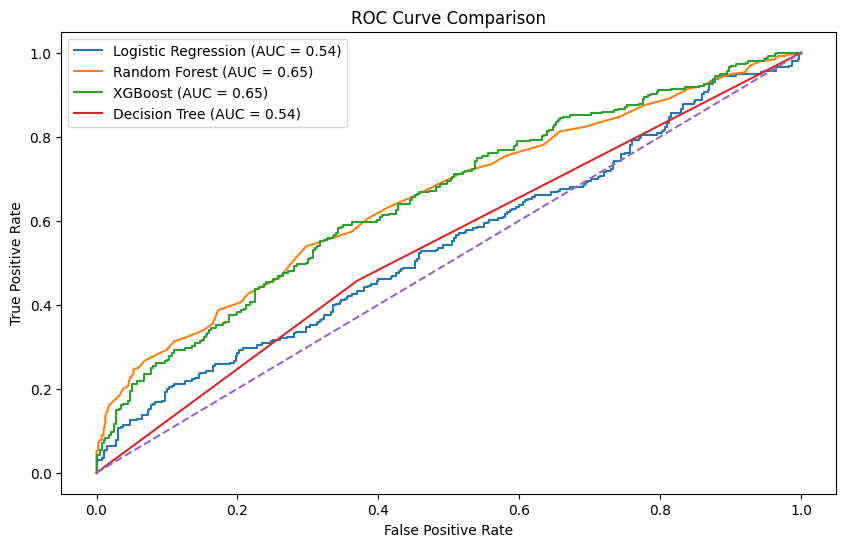

In [ ]:
plt.figure(figsize=(10, 6))

# Logistic Regression
plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc_logistic:.2f})"
)

# Random Forest
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.2f})"
)

# XGBoost
plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {roc_auc_xgb:.2f})"
)

# Decision Tree
plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {roc_auc_dt:.2f})"
)

# Random baseline
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

The ROC curves compare how well each model separates potable and non-potable water samples across different thresholds.

* XGBoost achieved the highest ROC-AUC score, showing the strongest overall ability to distinguish between the two classes.
* Random Forest also performed reasonably well and showed good classification ability.
* Decision Tree achieved strong F1 performance during cross-validation, but its ROC-AUC score was lower, suggesting weaker probability ranking performance.
* Logistic Regression performed only slightly better than random guessing, indicating that the dataset contains complex non-linear relationships.

Overall, the ROC analysis shows that tree-based ensemble models performed better than the linear model for this classification task.

In [ ]:
# Create feature dataframe used for training
X_features = df.drop(
    ["Potability", "Cluster"],
    axis=1,
    errors="ignore"
)

# Check number of columns
print(len(X_features.columns))

16


### **Comparing Feature Importance Across Models**

Feature importance analysis was performed to identify which variables contributed most to the predictions made by the tree-based models.

This helps explain how the models make decisions and which water quality measurements are most influential for predicting water potability.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [ ]:
X = df_encoded[[
    'ph',
    'Hardness',
    'Solids',
    'Chloramines',
    'Sulfate',
    'Conductivity',
    'Organic_carbon',
    'Trihalomethanes',
    'Turbidity',
    'chemical_load',
    'hardness_to_solids_ratio',
    'conductivity_per_solid',
    'safe_ph_flag',
    'contamination_risk_score',
    'ph_category_Neutral',
    'ph_category_Alkaline'
]]

In [ ]:
# Feature names
feature_names = X.columns

# Random Forest feature importance
rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_model.feature_importances_
})

# XGBoost feature importance
xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

# Decision Tree feature importance
dt_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": decision_tree_model.feature_importances_
})

In [ ]:
rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

dt_importance = dt_importance.sort_values(
    by="Importance",
    ascending=False
)

### **Top Features for Random Forest**

The Random Forest model identified pH, Hardness, Chloramines, and the engineered feature chemical_load as some of the most important predictors of water potability.

The results also show that engineered features such as hardness_to_solids_ratio and contamination_risk_score contributed strongly to the model. This suggests that combining existing water quality measurements helped the model capture more complex chemical relationships than using the original features alone.

The feature importance values were relatively spread out across many variables, indicating that water potability is influenced by multiple interacting factors rather than a single dominant feature.

This aligns with the earlier clustering analysis, where potable and non-potable water samples showed overlap across different chemical conditions.

In [ ]:
# Show top features
rf_importance.head(10)

,Feature,Importance
0,ph,0.093045
1,Hardness,0.088757
3,Chloramines,0.084275
9,chemical_load,0.078475
10,hardness_to_solids_ratio,0.075460
5,Conductivity,0.072438
6,Organic_carbon,0.071951
8,Turbidity,0.071772
13,contamination_risk_score,0.071124
2,Solids,0.070216


### **Top Features for XGBoost**

The feature importance results from the XGBoost model show that pH-related variables are the most influential predictors of water potability. Both the raw pH value and its engineered categorical representations contribute strongly to the model’s decisions, indicating that water acidity/alkalinity is a key factor in determining potability within the dataset.

Other important predictors include sulfate concentration and chloramines, which reflect underlying chemical composition and contamination levels. In addition, engineered features such as hardness ratios and contamination risk scores also contribute meaningfully to the model’s performance, suggesting that feature engineering enhanced the model’s ability to capture relevant patterns.

However, the presence of both raw and transformed pH variables may introduce redundancy, which could affect interpretability. This suggests a need for further feature refinement to ensure a more streamlined and non-overlapping feature set in future model iterations.


In [ ]:
xgb_importance.head(10)

,Feature,Importance
15,ph_category_Alkaline,0.112632
14,ph_category_Neutral,0.107280
4,Sulfate,0.068600
0,ph,0.067673
12,safe_ph_flag,0.063695
3,Chloramines,0.061746
9,chemical_load,0.057860
10,hardness_to_solids_ratio,0.057090
1,Hardness,0.056949
13,contamination_risk_score,0.055120


### **Top Features for Decision Tree**

The Decision Tree model identified pH as the most important feature for predicting water potability, confirming that acidity and alkalinity are major indicators of water safety across multiple models.

Chloramines also showed consistently high importance, suggesting that disinfectant chemical levels play a significant role in determining whether water is safe for consumption. The strong importance of Chloramines across different models indicates that it is a stable and influential predictor in the dataset.

The model also assigned meaningful importance to Sulfate, Turbidity, Trihalomethanes, and Conductivity, showing that both chemical composition and water clarity contribute to potability prediction.

Engineered features such as conductivity_per_solid and hardness_to_solids_ratio also appeared among the top predictors, confirming that feature engineering helped capture additional chemical relationships within the water samples.

Overall, the feature importance analysis shows that water potability depends on several interacting environmental and chemical conditions rather than a single dominant factor.


In [ ]:
dt_importance.head(10)

,Feature,Importance
0,ph,0.125089
3,Chloramines,0.096167
4,Sulfate,0.091866
8,Turbidity,0.085815
1,Hardness,0.077856
7,Trihalomethanes,0.077020
5,Conductivity,0.074134
11,conductivity_per_solid,0.071076
6,Organic_carbon,0.068563
10,hardness_to_solids_ratio,0.064963


In [ ]:
import pandas as pd

# RESULTS

# processing dataset
df_encoded.to_csv(
    'final_water_quality_dataset.csv',
    index=False
)

# classification results
comparison_table.to_csv(
    'classification_results.csv',
    index=False
)

# Save cross-validation results
cv_results.to_csv(
    'cross_validation_results.csv',
    index=False
)

# feature importance
# To save all feature importances, you might want to concatenate them into one DataFrame first
# For example:
feature_importance_combined = pd.concat([rf_importance.set_index('Feature'), xgb_importance.set_index('Feature'), dt_importance.set_index('Feature')], axis=1, keys=['Random_Forest', 'XGBoost', 'Decision_Tree'])
feature_importance_combined.to_csv(
    'feature_importance_combined.csv',
    index=True
)

In [ ]:
# FINAL CHECKLIST

# Final dataset preview
df_encoded.head()
# Final shape
df_encoded.shape

(3276, 17)

# **Part 7**

# **Question 22**
### **Which model would you deploy and why**?
The Random Forest model trained with SMOTE would be recommended for deployment because it achieved the best balance between recall and F1-score for the positive class. Although the XGBoost model showed strong overall performance, the Random Forest with SMOTE handled the class imbalance problem more effectively and performed better at identifying potable water samples.
Since the main objective of the project was to correctly detect safe drinking water, improving recall for the positive class was considered more important than achieving slightly higher overall accuracy. The model also produced more balanced prediction results across both classes.

## **Question 23**

## **What would you do differently if you had another month?**

If more time was available, additional feature engineering and hyperparameter tuning would be performed to further improve model performance. More extensive tuning of the XGBoost model could also be explored to improve recall and overall classification performance.

Additional domain knowledge about water chemistry could help create stronger engineered features related to contamination and mineral composition. Further work could also include deeper cross-validation experiments, threshold tuning, and testing additional imbalance handling techniques to improve prediction performance.

More time would also allow for building a cleaner end-to-end preprocessing pipeline earlier in the project to reduce feature consistency and debugging issues encountered during clustering and model evaluation.



and testing more imbalance handling techniques.



#**Question 24**
###**What did the clusters reveal that the classifier missed?**
The clustering analysis showed that water samples naturally formed different groups based on their chemical properties, especially pH levels, mineral concentration, and contamination patterns.
The analysis revealed that some groups with balanced chemical conditions had moderate potability rates, while the High Mineral Water cluster had the highest potability rate at about 49.5%. This suggests that water with higher mineral content is not always unsafe for drinking.
The clustering analysis also uncovered an extreme water composition group with a 0% potability rate, meaning every sample in that cluster was non-potable. This important pattern was not as clearly visible from the classification models alone.
At the same time, there was still noticeable overlap between potable and non-potable samples across several clusters. This shows that water potability is a complex problem influenced by multiple interacting factors rather than one single feature or perfectly separated group.

#**Question 25**
###**What was the hardest decision your team made and why?**
One of the hardest decisions was choosing how to handle the imbalanced dataset.
Improving recall for potable water samples often reduced overall accuracy and precision. It was necessary to balance detecting more positive cases while avoiding too many incorrect predictions.
Another difficult decision was selecting the final number of clusters because the elbow curve and silhouette scores suggested slightly different results. A balance had to be made between cluster quality and interpretability.